In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io, morphology, measure
from skimage.segmentation import find_boundaries
import warnings

# Paths

img_dir = r"C:\Users\eduar\Documents\Second Semester - DS\Project in Data Science\First Project\imgs"
mask_dir = r"C:\Users\eduar\Documents\Second Semester - DS\Project in Data Science\First Project\masks\masks"
border_dir = r"C:\Users\eduar\Documents\Second Semester - DS\Project in Data Science\First Project\Borders"

# Features

def preprocess_mask(mask):
    if mask.ndim == 3:
        mask = mask[:, :, 0]

    mask_bin = mask > 0

    mask_bin = morphology.remove_small_objects(mask_bin, min_size=100)
    mask_bin = morphology.remove_small_holes(mask_bin, area_threshold=100)

    return mask_bin

def get_main_lesion(mask_bin):
    labels = measure.label(mask_bin)
    regions = measure.regionprops(labels)

    if len(regions) == 0:
        return None, None

    largest = max(regions, key=lambda r: r.area)
    lesion = labels == largest.label

    return lesion, largest

def extract_features(mask):
    mask_bin = preprocess_mask(mask)
    lesion, region = get_main_lesion(mask_bin)

    if lesion is None:
        return None, None, None

    border = find_boundaries(lesion, mode="inner")

    area = region.area
    perimeter = region.perimeter

    features = {

    # Total number of pixels in the image (height × width)
    # Represents the full image size, independent of lesion size
    "total_pixels": mask.shape[0] * mask.shape[1],

    # Total area of the lesion (number of pixels inside the mask)
    # Represents the size of the lesion in the image
    "area": area,

    "lesion_percentage": area / (mask.shape[0] * mask.shape[1]),

    # Perimeter of the lesion (length of its boundary)
    # Measures how extensive the border is
    "perimeter": perimeter,

    # If >1 the higher irregularity it presents
    "compactness": (perimeter ** 2) / (4 * np.pi * area) if area > 0 else np.nan,

    # Solidity = area / convex hull area
    # Measures how "compact" the lesion is
    # Lower values indicate indentations or irregular edges
    "solidity": region.solidity,

    # Eccentricity (ranges from 0 to 1)
    # 0 → perfect circle
    # Close to 1 → highly elongated shape (ellipse-like)
    "eccentricity": region.eccentricity,

    # Number of pixels belonging to the lesion boundary
    # Another measure of border size/complexity
    "border_pixels": np.sum(border)
    }

    return lesion, border, features


In [ ]:

# Loop through images

rows = []

for mask_file in os.listdir(mask_dir):

    if not mask_file.lower().endswith(".png"):
        continue

    mask_path = os.path.join(mask_dir, mask_file)

    img_file = mask_file.replace("_mask", "")
    img_path = os.path.join(img_dir, img_file)

    if not os.path.exists(img_path):
        print(f"No image found: {img_file}")
        continue

    try:
        mask = io.imread(mask_path)

        lesion, border, features = extract_features(mask)

        if features is None:
            print(f"No lesion found: {mask_file}")
            continue

        # 🔹 SALVAR BORDA
        border_img = (border.astype(np.uint8)) * 255

        border_filename = mask_file.replace("_mask", "_border")
        border_path = os.path.join(border_dir, border_filename)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            io.imsave(border_path, border_img)

        # 🔹 SALVAR FEATURES
        features["image_name"] = img_file
        features["mask_name"] = mask_file

        rows.append(features)

    except Exception as e:
        print(f"Error in {mask_file}: {e}")

No lesion found: PAT_104_1755_320_mask.png
No image found: PAT_117_2_983.png


In [ ]:

# DATAFRAME + SAVE

df = pd.DataFrame(rows)

print(df.head())
print(f"\nNumber of images processed: {len(df)}")

df.to_csv("features_borders_lesions.csv", index=False)
print("\nSaved in: features_borders_lesions.csv")

   total_pixels      area  lesion_percentage    perimeter  compactness  \
0        370881   33075.0           0.089180   870.908730     1.824885   
1        101124    2510.0           0.024821   226.710678     1.629523   
2         68644    1401.0           0.020410   139.740115     1.109160   
3        519841  127640.0           0.245537  1630.077344     1.656608   
4         48841    2128.0           0.043570   195.296465     1.426288   

   irregularity_index  solidity  eccentricity  border_pixels  \
0            1.350883  0.870280      0.876960            757   
1            1.276528  0.934823      0.899874            206   
2            1.053167  0.979720      0.604603            124   
3            1.287093  0.911070      0.680126           1418   
4            1.194273  0.943681      0.805620            175   

            image_name                 mask_name  
0  PAT_1000_31_620.png  PAT_1000_31_620_mask.png  
1  PAT_1006_53_385.png  PAT_1006_53_385_mask.png  
2  PAT_1006_53_71

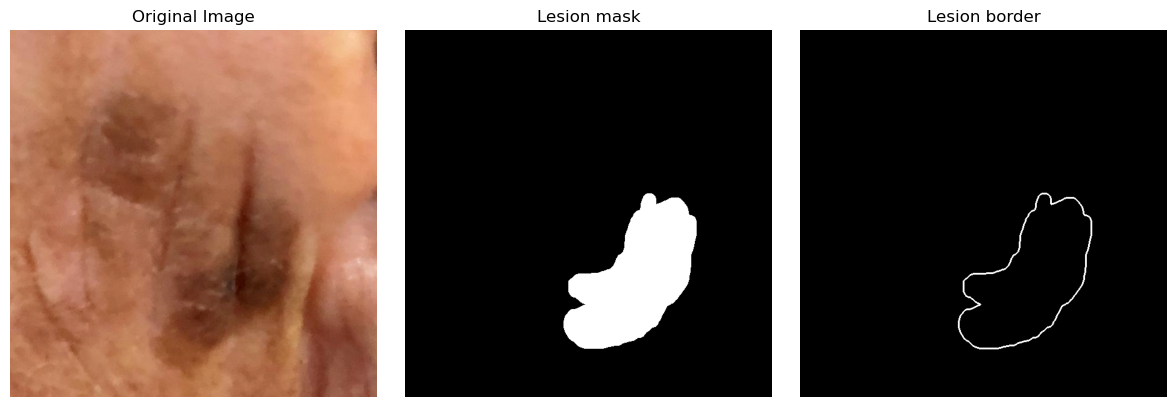

In [ ]:

# Get a sample

if len(df) > 0:
    sample_mask = df.iloc[0]["mask_name"]
    sample_img = df.iloc[0]["image_name"]

    mask = io.imread(os.path.join(mask_dir, sample_mask))
    im = io.imread(os.path.join(img_dir, sample_img))

    lesion, border, _ = extract_features(mask)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(im)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(lesion, cmap="gray")
    axes[1].set_title("Lesion mask")
    axes[1].axis("off")

    border_thick = morphology.dilation(border, morphology.disk(1))

    axes[2].imshow(border_thick, cmap="gray")
    axes[2].set_title("Lesion border")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# Paths
features_path = r"C:\Users\eduar\Documents\Second Semester - DS\Project in Data Science\First Project\features_borders_lesions.csv"
metadata_path = r"C:\Users\eduar\Documents\Second Semester - DS\Project in Data Science\First Project\metadata.csv"

# Load files
features_df = pd.read_csv(features_path)
metadata_df = pd.read_csv(metadata_path, index_col=0)

# Keep only the columns needed from metadata
metadata_df = metadata_df[["img_id", "diagnostic"]]

# Merge using image_name from features and img_id from metadata
merged_df = features_df.merge(
    metadata_df,
    left_on="image_name",
    right_on="img_id",
    how="left"
)

# Drop duplicate key column from metadata if you do not want it in the final file
merged_df = merged_df.drop(columns=["img_id"])

# Save back to CSV
output_path = r"C:\Users\eduar\Documents\Second Semester - DS\Project in Data Science\First Project\features_borders_lesions_diagnostic.csv"
merged_df.to_csv(output_path, index=False)

print("Diagnostic column added successfully.")
print(merged_df[["image_name", "diagnostic"]].head())

Diagnostic column added successfully.
            image_name diagnostic
0  PAT_1000_31_620.png        SEK
1  PAT_1006_53_385.png        ACK
2  PAT_1006_53_716.png        ACK
3  PAT_1008_59_297.png        SEK
4  PAT_100_393_898.png        NEV
